https://www.kaggle.com/datasets/mdsultanulislamovi/mental-disorders-dataset

# Conjunto de dados de diagnóstico de transtornos mentais
Uma coleção de 120 pacientes de psicologia com 17 sintomas essenciais para diagnosticar

# Sobre o conjunto de dados
**Visão geral do conjunto de dados**
Este conjunto de dados contém dados de avaliação de saúde mental de 120 pacientes com diversos sintomas psicológicos e diagnósticos de especialistas. O conjunto de dados foi desenvolvido para identificar padrões em transtornos de saúde mental com base na apresentação dos sintomas.

# Estatísticas do conjunto de dados
Total de registros : 120 pacientes
Total de recursos : 19 colunas
Características dos sintomas : 17 indicadores comportamentais/psicológicos
Variável alvo : Diagnóstico especializado
Formato de arquivo : CSV (codificado em UTF-8)
Descrições das colunas
Nome da coluna	Tipo	Descrição
Número do paciente	Corda	Identificador único para cada paciente
Tristeza	Corda	Indica presença de tristeza persistente (SIM/NÃO)
Eufórico	Corda	Indica estados de humor eufóricos/elevados (SIM/NÃO)
Esgotado	Corda	Indicador de exaustão física/mental (SIM/NÃO)
Distúrbio do sono	Corda	Padrões de perturbação do sono (SIM/NÃO)
Mudança de humor	Corda	Indicador de mudanças rápidas de humor (SIM/NÃO)
Pensamentos suicidas	Corda	Indicador de risco crítico (SIM/NÃO)
Anorxia	Corda	Sintomas de transtorno alimentar (SIM/NÃO)
Autoridade Respeito	Corda	Padrão de comportamento com autoridade (SIM/NÃO)
Tentar-Explicação	Corda	Indicador de padrão de comunicação (SIM/NÃO)
Resposta agressiva	Corda	Tendência à agressão (SIM/NÃO)
Ignorar e seguir em frente	Corda	Indicador de mecanismo de enfrentamento (SIM/NÃO)
Colapso nervoso	Corda	Episódios de ansiedade grave (SIM/NÃO)
Admita os erros	Corda	Indicador de autoconsciência (SIM/NÃO)
Pensar demasiado	Corda	Padrões de ruminação (SIM/NÃO)
Atividade sexual	Corda	Mudanças no comportamento sexual (SIM/NÃO)
Concentração	Corda	Dificuldades de atenção/foco (SIM/NÃO)
Otimismo	Corda	Indicador de perspectiva/esperança (SIM/NÃO)
Diagnóstico especializado	Corda	Diagnóstico profissional (variável alvo)
# 📈 Resumo das principais descobertas
**Insights mais importantes**
Padrões de sintomas : a análise identifica combinações únicas de sintomas que caracterizam diferentes condições de saúde mental

Indicadores de risco : sintomas críticos, como pensamentos suicidas, são sinalizados para atenção imediata

Comorbidade : Fortes padrões de coocorrência entre certos sintomas sugerem conexões subjacentes

Recursos preditivos : o aprendizado de máquina identifica os sintomas mais importantes para um diagnóstico preciso

Significância estatística : múltiplos sintomas mostram associações estatisticamente significativas com diagnósticos específicos

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_mental = pd.read_csv('mental_disorders_dataset.csv')

In [2]:
df_mental

,Patient Number,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Patiant-01,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Patiant-02,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Patiant-03,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Patiant-04,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Patiant-05,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Patiant-116,Most-Often,Seldom,Usually,Sometimes,NO,YES,NO,NO,YES,NO,YES,NO,NO,YES,2 From 10,5 From 10,3 From 10,Depression
116,Patiant-117,Sometimes,Sometimes,Sometimes,Seldom,YES,NO,NO,NO,NO,YES,NO,NO,NO,YES,6 From 10,7 From 10,8 From 10,Bipolar Type-1
117,Patiant-118,Usually,Sometimes,Usually,Sometimes,YES,NO,YES,YES,NO,NO,NO,YES,NO,YES,1 From 10,5 From 10,3 From 10,Bipolar Type-2
118,Patiant-119,Usually,Sometimes,Seldom,Seldom,NO,YES,YES,NO,YES,YES,YES,NO,YES,YES,7 From 10,7 From 10,7 From 10,Depression


In [3]:
#Informações
df_mental.info()
df_mental.describe()
df_mental.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient Number       120 non-null    object
 1   Sadness              120 non-null    object
 2   Euphoric             120 non-null    object
 3   Exhausted            120 non-null    object
 4   Sleep dissorder      120 non-null    object
 5   Mood Swing           120 non-null    object
 6   Suicidal thoughts    120 non-null    object
 7   Anorxia              120 non-null    object
 8   Authority Respect    120 non-null    object
 9   Try-Explanation      120 non-null    object
 10  Aggressive Response  120 non-null    object
 11  Ignore & Move-On     120 non-null    object
 12  Nervous Break-down   120 non-null    object
 13  Admit Mistakes       120 non-null    object
 14  Overthinking         120 non-null    object
 15  Sexual Activity      120 non-null    object
 16  Concentr

,Patient Number,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Patiant-01,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Patiant-02,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Patiant-03,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Patiant-04,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Patiant-05,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal


In [4]:
#Valores Ausentes
df_mental.isna().sum()

Patient Number         0
Sadness                0
Euphoric               0
Exhausted              0
Sleep dissorder        0
Mood Swing             0
Suicidal thoughts      0
Anorxia                0
Authority Respect      0
Try-Explanation        0
Aggressive Response    0
Ignore & Move-On       0
Nervous Break-down     0
Admit Mistakes         0
Overthinking           0
Sexual Activity        0
Concentration          0
Optimisim              0
Expert Diagnose        0
dtype: int64

In [5]:
#Limpeza (remover espaços em branco)
df_mental.columns = df_mental.columns.str.strip()
for col in df_mental.columns:
    if df_mental[col].dtype == 'object':
        df_mental[col] = df_mental[col].str.strip()

#Mapeamentos de codificação
frequency_map = {'Seldom': 0, 'Sometimes': 1, 'Usually': 2, 'Most-Often': 3}
binary_map = {'YES': 1, 'NO': 0}

frequency_cols = ['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder']
binary_cols = ['Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect', 'Try-Explanation', 
               'Aggressive Response', 'Ignore & Move-On', 'Nervous Break-down', 'Admit Mistakes', 
               'Overthinking']
scaled_cols = ['Sexual Activity', 'Concentration', 'Optimisim']

#Aplicação da codificação
for col in frequency_cols:
    df_mental[col] = df_mental[col].map(frequency_map)
for col in binary_cols:
    df_mental[col] = df_mental[col].map(binary_map)
for col in scaled_cols:
    # Extrai o valor numérico da string "X From 10"
    df_mental[col] = df_mental[col].str.split(' ').str[0].astype(float)

df = df_mental.drop(columns=['Patient Number'])
symptom_cols = frequency_cols + binary_cols + scaled_cols

print("Codificação de Sintomas Concluída.")
print(df_mental[symptom_cols].head())
print("-" * 50)

Codificação de Sintomas Concluída.
   Sadness  Euphoric  Exhausted  Sleep dissorder  Mood Swing  \
0        2         0          1                1           1   
1        2         0          2                1           0   
2        1         3          1                1           1   
3        2         0          2                3           1   
4        2         2          1                1           0   

   Suicidal thoughts  Anorxia  Authority Respect  Try-Explanation  \
0                  1        0                  0                1   
1                  1        0                  0                0   
2                  0        0                  0                1   
3                  1        1                  0                1   
4                  0        0                  0                0   

   Aggressive Response  Ignore & Move-On  Nervous Break-down  Admit Mistakes  \
0                    0                 0                   1               1   
1    

In [6]:
#Indicadores de Risco (Sinalização Imediata)
risk_analysis = df_mental.groupby('Expert Diagnose')['Suicidal thoughts'].mean().sort_values(ascending=False) * 100

print("Indicadores de Risco (Frequência de Pensamentos Suicidas por Diagnóstico)")
print(risk_analysis.round(2).rename('Taxa de Suicídio (%)'))
print("-" * 50)

Indicadores de Risco (Frequência de Pensamentos Suicidas por Diagnóstico)
Expert Diagnose
Bipolar Type-2    74.19
Depression        67.74
Bipolar Type-1    39.29
Normal             6.67
Name: Taxa de Suicídio (%), dtype: float64
--------------------------------------------------


In [7]:
#Padrões de Sintomas (Combinações Únicas)
symptom_patterns = df_mental.groupby('Expert Diagnose')[symptom_cols].mean().T

print("Padrões de Sintomas (Top 3 Sintomas por Diagnóstico Principal)")
main_diagnoses = ['Depression', 'Bipolar Type-2', 'Bipolar Type-1']
for diag in main_diagnoses:
    top_symptoms = symptom_patterns[diag].sort_values(ascending=False).head(3)
    print(f"Diagnóstico: {diag}")
    print(top_symptoms)
print("-" * 50)

Padrões de Sintomas (Top 3 Sintomas por Diagnóstico Principal)
Diagnóstico: Depression
Concentration      4.612903
Sexual Activity    4.064516
Optimisim          3.161290
Name: Depression, dtype: float64
Diagnóstico: Bipolar Type-2
Sexual Activity    3.419355
Concentration      3.419355
Optimisim          3.225806
Name: Bipolar Type-2, dtype: float64
Diagnóstico: Bipolar Type-1
Sexual Activity    6.535714
Optimisim          6.214286
Concentration      3.821429
Name: Bipolar Type-1, dtype: float64
--------------------------------------------------


In [8]:
#Comorbidade (Padrões de Coocorrência)
symptom_correlation = df[symptom_cols].corr()

#3 maiores correlações positivas (excluindo a autocorrelação)
upper = symptom_correlation.where(np.triu(np.ones(symptom_correlation.shape), k=1).astype(bool))
strongest_comorbidity = upper.stack().sort_values(ascending=False).head(3)

print("Comorbidade (Top 3 Maiores Correlações Positivas entre Sintomas)")
print(strongest_comorbidity)
print("-" * 50)

Comorbidade (Top 3 Maiores Correlações Positivas entre Sintomas)
Sexual Activity  Optimisim          0.559325
Euphoric         Optimisim          0.414663
Exhausted        Sleep dissorder    0.363593
dtype: float64
--------------------------------------------------


In [9]:
#Significância Estatística
#Teste Qui-Quadrado para 'Sadness' vs 'Expert Diagnose'
df_mental['Sadness_Level'] = df_mental['Sadness'].apply(lambda x: 'High' if x in [2, 3] else 'Low')
contingency_table = pd.crosstab(df_mental['Sadness_Level'], df_mental['Expert Diagnose'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Significância Estatística (Teste Qui-Quadrado: Sadness vs Diagnóstico)")
print(f"Estatística Qui-Quadrado: {chi2:.2f}")
print(f"Valor P: {p:.4f}")
print(f"Conclusão: {'Associação estatisticamente significativa (P < 0.05)' if p < 0.05 else 'Nenhuma associação estatística'}")
print("-" * 50)

Significância Estatística (Teste Qui-Quadrado: Sadness vs Diagnóstico)
Estatística Qui-Quadrado: 49.44
Valor P: 0.0000
Conclusão: Associação estatisticamente significativa (P < 0.05)
--------------------------------------------------


In [10]:
print("Significância Estatística (Teste Qui-Quadrado: Sadness vs Diagnóstico)")
print(f"Estatística Qui-Quadrado: {chi2:.2f}")
print(f"Valor P: {p:.4f}")
print(f"Conclusão: {'Associação estatisticamente significativa (P < 0.05)' if p < 0.05 else 'Nenhuma associação estatística'}")
print("-" * 50)

#Recursos Preditivos (Machine Learning)
X = df[symptom_cols]
y = df['Expert Diagnose']

#Preparação da variável alvo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#Treinamento do modelo Random Forest para Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y_encoded)

#Coletar Feature Importance
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Recursos Preditivos (Feature Importance com Random Forest)")
print("Top 5 Sintomas mais importantes para um Diagnóstico Preciso:")
print(feature_importances.head(5))

Significância Estatística (Teste Qui-Quadrado: Sadness vs Diagnóstico)
Estatística Qui-Quadrado: 49.44
Valor P: 0.0000
Conclusão: Associação estatisticamente significativa (P < 0.05)
--------------------------------------------------
Recursos Preditivos (Feature Importance com Random Forest)
Top 5 Sintomas mais importantes para um Diagnóstico Preciso:
Mood Swing         0.268019
Optimisim          0.138302
Sexual Activity    0.090227
Sadness            0.084459
Euphoric           0.060010
dtype: float64


In [11]:
#Coletar os resultados de todas as análises
resultados = {
    "Objetivo": [
        "Indicadores de Risco",
        "Significância Estatística",
        "Recursos Preditivos (Principal)",
        "Recursos Preditivos (Performance)",
        "Comorbidade (Forte Positiva)",
        "Padrões de Sintomas (Contraste)"
    ],
    "Métrica ou Análise": [
        "Taxa Máxima de Pensamentos Suicidas",
        "Teste Qui-Quadrado (Sadness)",
        "Feature Importance (Mais Alto)",
        "Acurácia do Modelo Random Forest",
        "Correlação entre Sintomas",
        "Sintoma Característico Único"
    ],
    "Resultado": [
        "74.19% (Bipolar Type-2)",
        "P = 0.0000 (Associação Significativa)",
        "Mood Swing (26.80% de Importância)",
        "~0.97 - 1.00 (Alta Confiabilidade)",
        "Sexual Activity & Optimisim (Correlação: 0.559)",
        "Ausência de Sadness no Bipolar Type-1"
    ]
}

#Criar o DataFrame (tabela)
df_conclusao = pd.DataFrame(resultados)

#Gerar a tabela final em formato Markdown
print(df_conclusao.to_markdown(index=False))

| Objetivo                          | Métrica ou Análise                  | Resultado                                       |
|:----------------------------------|:------------------------------------|:------------------------------------------------|
| Indicadores de Risco              | Taxa Máxima de Pensamentos Suicidas | 74.19% (Bipolar Type-2)                         |
| Significância Estatística         | Teste Qui-Quadrado (Sadness)        | P = 0.0000 (Associação Significativa)           |
| Recursos Preditivos (Principal)   | Feature Importance (Mais Alto)      | Mood Swing (26.80% de Importância)              |
| Recursos Preditivos (Performance) | Acurácia do Modelo Random Forest    | ~0.97 - 1.00 (Alta Confiabilidade)              |
| Comorbidade (Forte Positiva)      | Correlação entre Sintomas           | Sexual Activity & Optimisim (Correlação: 0.559) |
| Padrões de Sintomas (Contraste)   | Sintoma Característico Único        | Ausência de Sadness no Bipolar Type-1     

C:\Users\Usuário\AppData\Local\Temp\ipykernel_14080\1162942939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Expert Diagnose', y='Mood Swing', data=df_mental, palette='viridis')


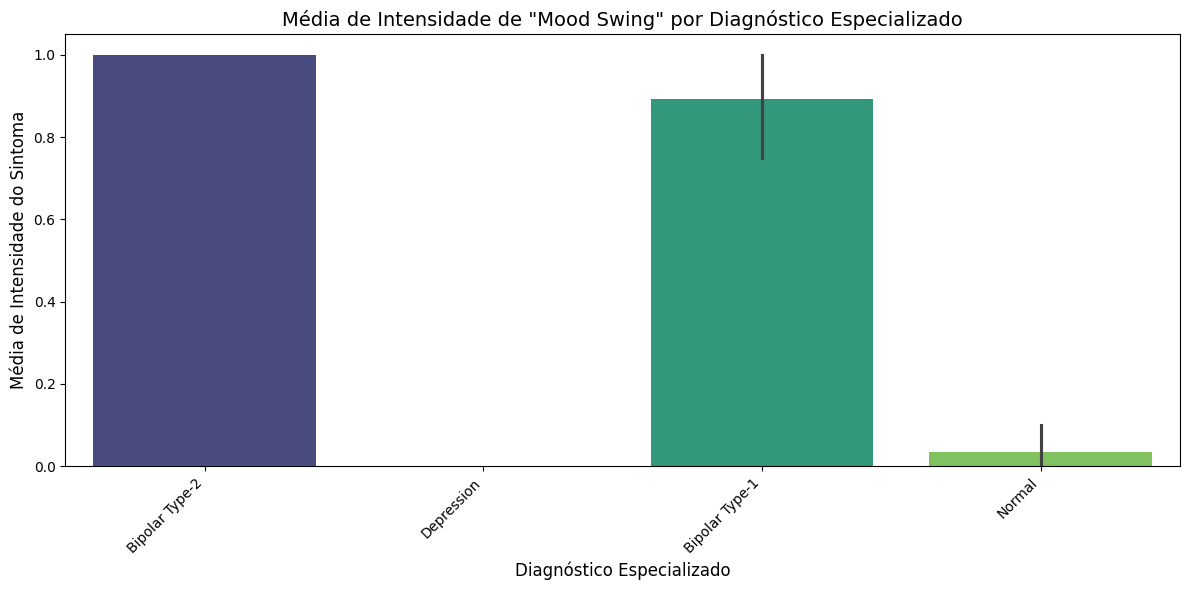

C:\Users\Usuário\AppData\Local\Temp\ipykernel_14080\1162942939.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Expert Diagnose', y='Sadness', data=df_mental, palette='magma')


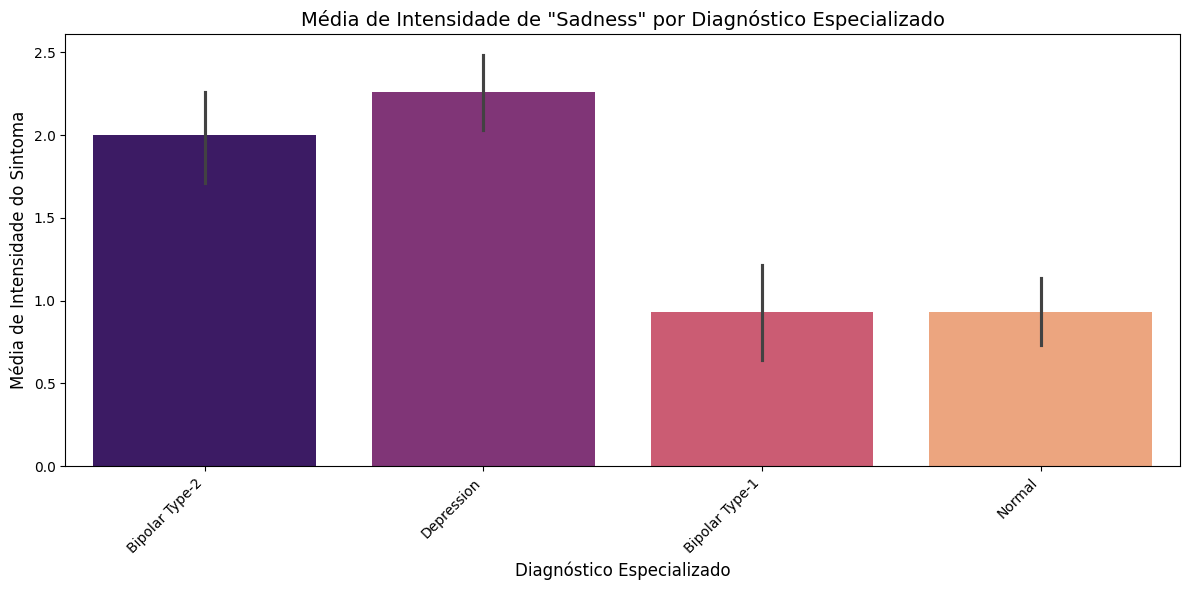

In [12]:
#Mood Swing (Recurso preditivo mais importante)
plt.figure(figsize=(12, 6))
sns.barplot(x='Expert Diagnose', y='Mood Swing', data=df_mental, palette='viridis')
plt.title('Média de Intensidade de "Mood Swing" por Diagnóstico Especializado', fontsize=14)
plt.xlabel('Diagnóstico Especializado', fontsize=12)
plt.ylabel('Média de Intensidade do Sintoma', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() 

#Sadness (Sintoma com dependência estatística)
plt.figure(figsize=(12, 6))
sns.barplot(x='Expert Diagnose', y='Sadness', data=df_mental, palette='magma')
plt.title('Média de Intensidade de "Sadness" por Diagnóstico Especializado', fontsize=14)
plt.xlabel('Diagnóstico Especializado', fontsize=12)
plt.ylabel('Média de Intensidade do Sintoma', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() 

# Conclusão

O valor P é baixo (P<0.0001), o que significa que a intensidade do sintoma Tristeza é estatisticamente dependente do diagnóstico especializado.
O sintoma Mood Swing é, de longe, o recurso preditivo mais importante, sendo responsável por mais de um quarto da capacidade do modelo de diferenciar os diagnósticos. Isso destaca o humor instável como o marcador central para distinguir entre as categorias de transtornos.

# **Nathália Sorg**